# Guia practica: sistema de Lorenz con Runge-Kutta de cuarto orden

Este notebook resuelve el sistema del inciso con la notacion `W`, `T1` y `T2`, usando `y_0 = (0, 0.5, 0.5)`, `Pr = 10`, `b = 8/3`, `dt = 0.005` y `0 <= t <= 50`. El objetivo no es solo reproducir figuras, sino interpretar criticamente la transicion desde un equilibrio estable hacia un comportamiento caotico.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().resolve().parents[0]
SUMMARY_PATH = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'resumen_lorenz_rk4.json'
with SUMMARY_PATH.open('r', encoding='utf-8') as f:
    summary = json.load(f)

summary['parameters']

{'Pr': 10.0,
 'b': 2.6666666666666665,
 'dt': 0.005,
 't_stop': 50.0,
 'initial_condition': [0.0, 0.5, 0.5],
 'perturbed_initial_condition': [0.0, 0.5, 0.50001]}

## Sistema y esquema numerico

Se resolvio el sistema

$$\frac{dW}{dt} = Pr (T_1 - W), \quad \frac{dT_1}{dt} = -W T_2 + rW - T_1, \quad \frac{dT_2}{dt} = W T_1 - bT_2$$

con `Pr = 10`, `b = 8/3`, `dt = 0.005` y condicion inicial base `y_0 = (0, 0.5, 0.5)`. La implementacion numerica sigue la estructura clasica de `RK4`; la lectura del problema se centra en comparar la evolucion temporal de `T1(t)` y `T2(t)` con la trayectoria en el espacio de fases `W-T1-T2`.

## Caso `r = 2`: evolucion temporal de `T1(t)` y `T2(t)`

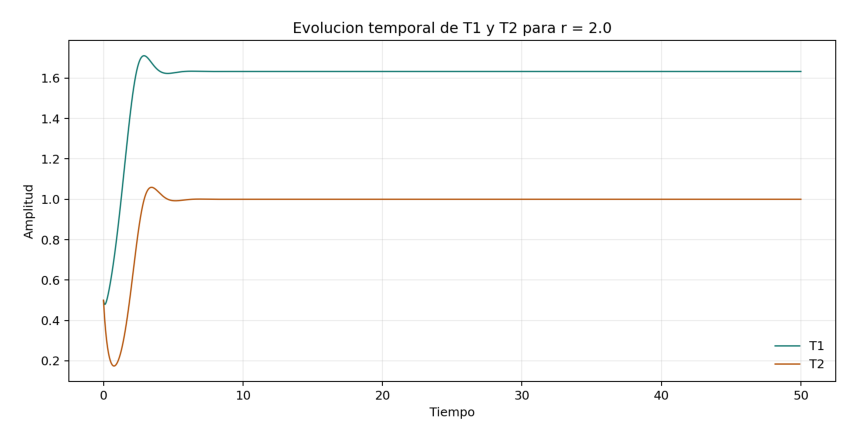

In [2]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r2_t1_t2.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

La lectura clave de este caso es la amortiguacion. `T1` y `T2` pierden variabilidad y convergen hacia valores casi constantes, lo que indica un equilibrio estable. Este caso sirve como referencia para distinguir despues los regimens transicionales y caoticos.

## Casos `r = 10` y `r = 24`: evolucion temporal de `T1(t)` y `T2(t)`

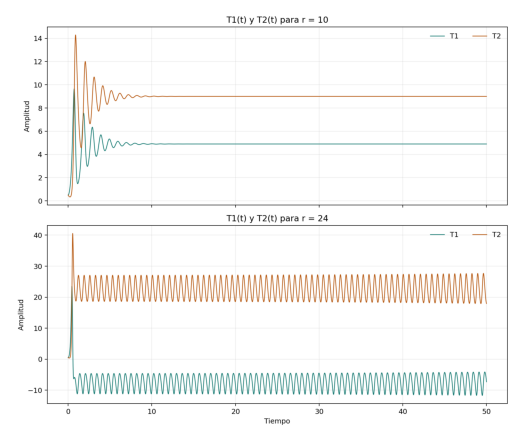

In [3]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r10_r24_t1_t2.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Caso `r = 10`: collage temporal-fases estilo MATLAB

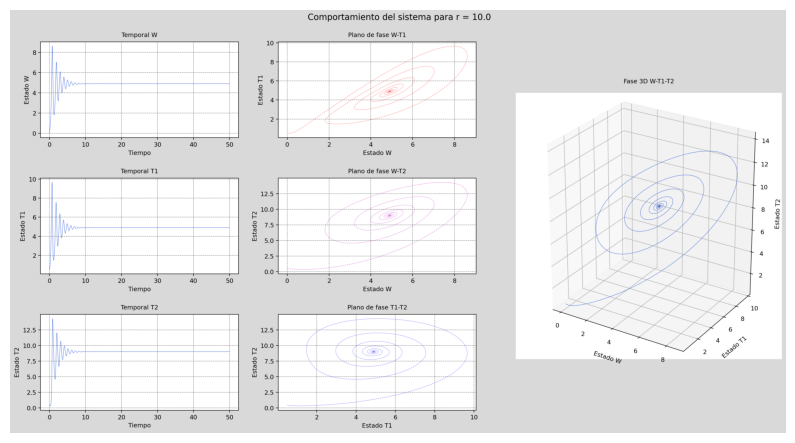

In [4]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r10_collage_matlab.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Caso `r = 24`: collage temporal-fases estilo MATLAB

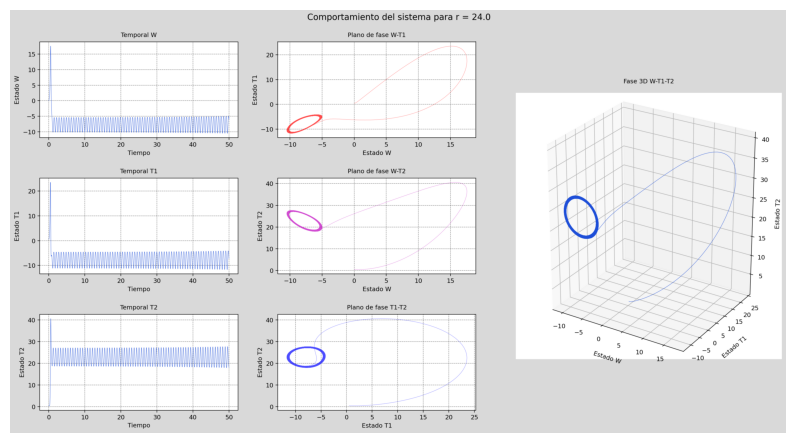

In [5]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r24_collage_matlab.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

La comparacion entre estos dos casos es crucial. El collage, ahora fiel a la organizacion usada en MATLAB, permite leer a la vez las tres series temporales, las tres proyecciones de fase 2D y la trayectoria 3D. En `r = 10`, todas esas vistas siguen concentrandose alrededor de un equilibrio. En `r = 24`, en cambio, aparecen recorridos mas amplios y cambios entre regiones del espacio de fases, lo que marca un regimen transicional.

## Caso `r = 25`: evolucion temporal de `T1(t)` y `T2(t)`

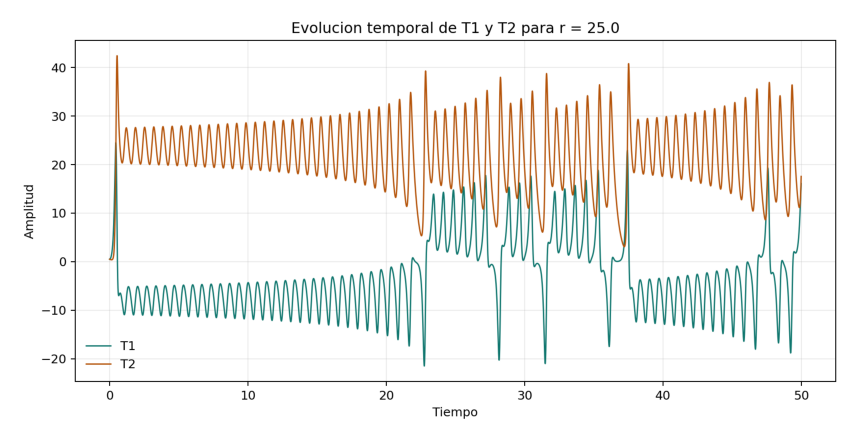

In [6]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r25_t1_t2.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Caso `r = 25`: collage temporal-fases estilo MATLAB

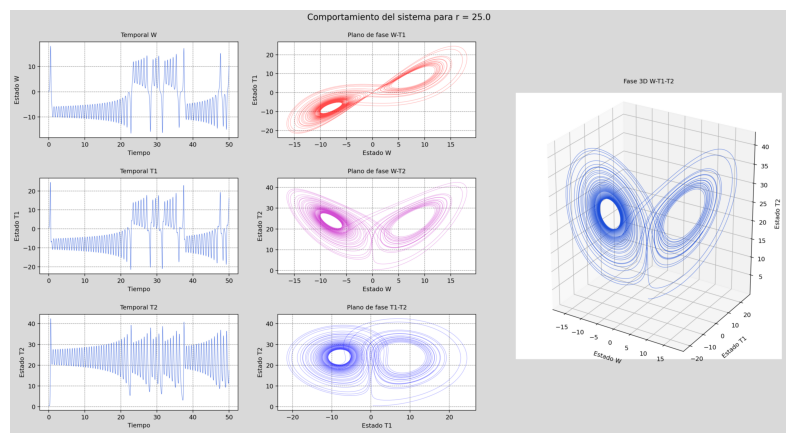

In [7]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r25_collage_matlab.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

En `r = 25` la interpretacion es mas nítida que en `r = 24`: el sistema ya no solo parece irregular, sino que muestra una dinamica persistentemente no periodica dentro de una estructura atractora acotada. La comparacion entre ambos casos ayuda a evitar una lectura apresurada de `r = 24` como si fuera un equilibrio muy lento.

## Caso `r = 30`: collage temporal-fases estilo MATLAB

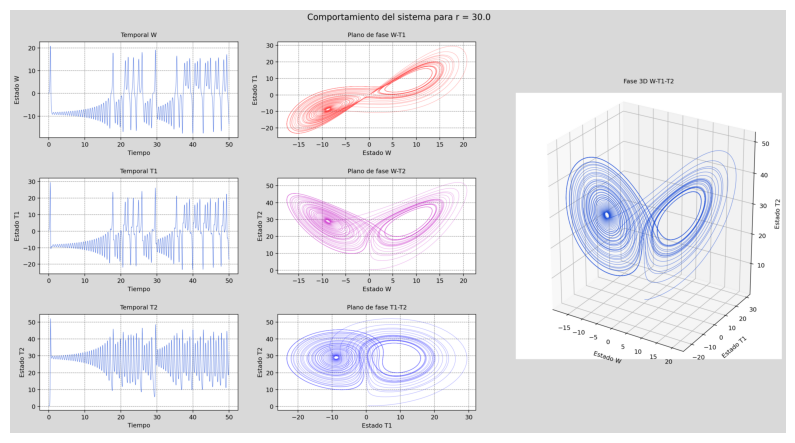

In [8]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r30_collage_matlab.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

## Caso `r = 30`: animacion de trayectorias en el espacio de fases

![Animacion del atractor para r = 30](../content/files_lorenz_rk4/lorenz_r30_fases_animacion.gif)

## Caso `r = 30`: evolucion temporal de `T1(t)` y sensibilidad a condiciones iniciales

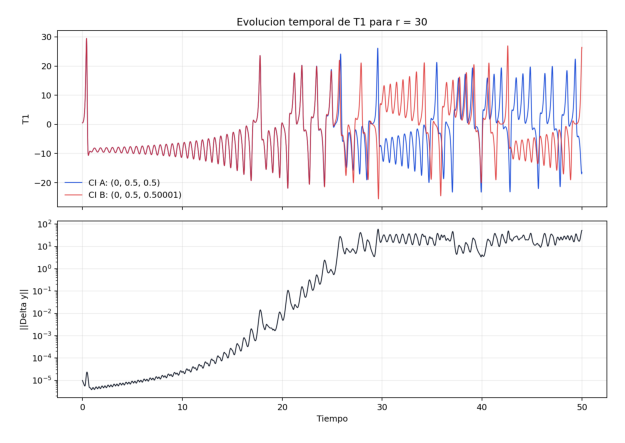

In [9]:
image_path = BASE_DIR / 'content' / 'files_lorenz_rk4' / 'lorenz_r30_t1_sensibilidad.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.5))
plt.imshow(img)
plt.axis('off')
plt.show()

La lectura conjunta del collage, de la primera animacion y de la serie temporal de `T1` permite fijar la conclusion principal del caso `r = 30`. Las dos trayectorias parten de estados casi indistinguibles, permanecen dentro del mismo atractor y, sin embargo, pierden rapidamente la coincidencia punto a punto. Esto significa que el sistema conserva una estructura geometrica global robusta, pero pierde predictibilidad puntual en horizontes de tiempo finitos, que es precisamente la firma del caos determinista.

## Caso `r = 30`: animacion de cinco trayectorias cercanas

![Animacion de cinco trayectorias cercanas para r = 30](../content/files_lorenz_rk4/lorenz_r30_multitrayectorias_animacion.gif)

La segunda animacion amplia la interpretacion anterior desde una sola pareja de trayectorias hacia un pequeño conjunto de orbitas vecinas. Su interes analitico es mostrar que la sensibilidad a condiciones iniciales no depende de una eleccion especialmente desafortunada de dos estados iniciales, sino que es una propiedad estructural del regimen caotico para `r = 30`. Las cinco trayectorias quedan confinadas dentro de la misma geometria global del atractor, pero recorren con rapidez regiones distintas del espacio de fases y distribuyen de forma desigual sus tiempos de permanencia en cada lobo. Esta observacion es clave porque anticipa una idea mas profunda: en sistemas caoticos, la trayectoria puntual deja de ser reproducible a largo plazo, pero la estructura estadistica del atractor sigue siendo interpretable y comparable mediante observables resumidos.

## Resumen numerico

In [10]:
rows = []
for key, values in summary['cases'].items():
    rows.append({
        'r': key,
        'std_T1_ultimos_10': round(values['t1_std_last_10_time_units'], 4),
        'std_T2_ultimos_10': round(values['t2_std_last_10_time_units'], 4),
        'dist_min_equilibrio_no_trivial': None if values['min_distance_nonzero_fixed_point'] is None else round(values['min_distance_nonzero_fixed_point'], 4),
        'T1_min': round(values['t1_min'], 4),
        'T1_max': round(values['t1_max'], 4),
    })
rows

[{'r': '2.0',
  'std_T1_ultimos_10': 0.0,
  'std_T2_ultimos_10': 0.0,
  'dist_min_equilibrio_no_trivial': 0.0,
  'T1_min': 0.4797,
  'T1_max': 1.7109},
 {'r': '10.0',
  'std_T1_ultimos_10': 0.0,
  'std_T2_ultimos_10': 0.0,
  'dist_min_equilibrio_no_trivial': 0.0,
  'T1_min': 0.4973,
  'T1_max': 9.6574},
 {'r': '24.0',
  'std_T1_ultimos_10': 2.5574,
  'std_T2_ultimos_10': 3.3157,
  'dist_min_equilibrio_no_trivial': 3.5803,
  'T1_min': -11.6984,
  'T1_max': 23.5327},
 {'r': '25.0',
  'std_T1_ultimos_10': 6.5353,
  'std_T2_ultimos_10': 6.9335,
  'dist_min_equilibrio_no_trivial': 3.1671,
  'T1_min': -21.5034,
  'T1_max': 24.5249},
 {'r': '30.0',
  'std_T1_ultimos_10': 8.9238,
  'std_T2_ultimos_10': 9.0076,
  'dist_min_equilibrio_no_trivial': 0.7186,
  'T1_min': -23.2528,
  'T1_max': 29.4837}]

In [11]:
summary['sensitivity_r30']

{'divergence_time_norm_gt_1': 24.080000000000002,
 'divergence_time_norm_gt_5': 25.54,
 'final_distance': 52.64216883186468}

## Cierre interpretativo

El patron general del capitulo es claro: al aumentar `r`, el sistema pasa de amortiguar perturbaciones a sostener oscilaciones persistentes y, finalmente, a mostrar sensibilidad extrema a condiciones iniciales. La implementacion de `RK4` permite capturar bien esa transicion, pero el aprendizaje principal proviene de comparar criticamente las salidas temporales y el espacio de fases en conjunto.